## **ReAct 루프**

**ReAct: Synergizing Reasoning and Acting in Language Models** 
(언어 모델에서의 추론과 행동의 시너지 창출)
- 2023년 ICLR(International Conference on Learning Representations)에 발표된 논문

- LLM이 **생각하기(Thought)** 와 **행동하기(Action)** 를 번갈아 하면서, 행동의 결과(Observation)를 다시 다음 생각에 반영합니다. 
- 이 세 가지가 한 사이클을 이루고, 모델은 매 사이클마다 "이미 관찰한 사실"을 근거로 다음 판단을 갱신합니다.

#### 🦜🔗 LangChain/LangGraph: ReAct는 `create_agent`가 이미 구현되어 있습니다
앞의 샘플에서 반복해서 구현한 "모델 호출 → 도구 호출 확인 → 실행 → 결과를 다시
모델에 전달 → 반복" 루프가 바로 ReAct 사이클입니다. `langchain.agents.create_agent(model,
tools, system_prompt)`는 이 루프 전체를 LangGraph 그래프로 미리 구현해 둔 것입니다. 이번
노트북에서는 `agent.stream(..., stream_mode="updates")`로 각 단계(모델의 생각+도구 호출,
도구 실행 결과)를 하나씩 들여다보면서 Thought/Action/Observation을 직접 출력해 보겠습니다.

In [1]:
import random
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

@tool
def calculator(expression: str) -> str:
    """사칙연산 수식을 계산합니다."""
    # 학습용 eval → 실제 서비스에선 안전한 파서 권장
    # (일부러 3번에 1번만 결과를 반환해 ReAct가 재시도하는 모습을 보여줍니다)
    return str(eval(expression)) if random.randint(1, 3) == 1 else ""

llm = ChatOpenAI(model="gpt-4o-mini")
calc_agent = create_agent(model=llm, tools=[calculator])


def run(question: str) -> str:
    """agent.stream(..., stream_mode="updates")으로 ReAct의 각 단계를 그대로 관찰합니다."""
    final_answer = ""
    for step in calc_agent.stream(
        {"messages": [{"role": "user", "content": question}]}, stream_mode="updates"
    ):
        for node_name, node_output in step.items():
            for m in node_output["messages"]:
                if node_name == "tools":
                    print(f"  [Observation] {m.content}")
                else:
                    if getattr(m, "tool_calls", None):
                        print(f"  [Action] {m.tool_calls}")
                    if m.content:
                        final_answer = m.content
    return final_answer


In [2]:
answer = run("153 곱하기 27은 얼마야? 계산기로 정확히 확인해줘.")
print("최종 답변:", answer)

  [Action] [{'name': 'calculator', 'args': {'expression': '153 * 27'}, 'id': 'call_anh1K7WkwsJNlKkT15RJ0vzY', 'type': 'tool_call'}]
  [Observation] 
  [Action] [{'name': 'calculator', 'args': {'expression': '153*27'}, 'id': 'call_q8cOOCHGNJ2NUXO9Bzljf4A6', 'type': 'tool_call'}]
  [Observation] 
  [Action] [{'name': 'calculator', 'args': {'expression': '153 * 27'}, 'id': 'call_AjdPC8dE8OZDceKoF26jHq5M', 'type': 'tool_call'}]
  [Observation] 4131
최종 답변: 153 곱하기 27은 4131입니다.


In [ ]:
answer = run("1에 2를 더하고 이 결과에 4를 곱하면 얼마야? 계산기로 정확히 확인해줘.")
print("최종 답변:", answer)

----

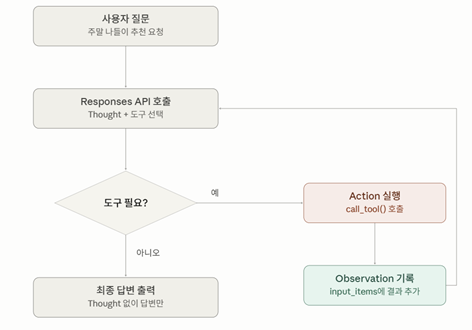

In [ ]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
import json

MODEL = "gpt-4o-mini"

# ------------------------------------------------------------
# 1. Toy Database  (원본과 동일하게 유지)
# ------------------------------------------------------------
# 외부 API를 쓰지 않고도 ReAct 흐름을 연습할 수 있도록
# 날씨, 장소, 비용 정보를 코드 안에 작게 넣어둡니다.

WEATHER_DB = {
    ("서울", "토요일"): {
        "condition": "비",
        "temperature_c": 24,
        "summary": "오후에 비가 올 가능성이 높습니다. 실내 활동을 추천합니다.",
    },
    ("서울", "일요일"): {
        "condition": "맑음",
        "temperature_c": 28,
        "summary": "대체로 맑고 야외 활동하기 좋습니다.",
    },
    ("부산", "토요일"): {
        "condition": "흐림",
        "temperature_c": 25,
        "summary": "흐리지만 비 가능성은 낮습니다.",
    },
}

PLACE_DB = [
    {
        "city": "서울",
        "name": "국립중앙박물관",
        "type": "문화",
        "indoor": True,
        "price_per_person": 0,
        "duration_hours": 2.5,
        "description": "비 오는 날에도 편하게 볼 수 있는 대형 실내 전시 공간입니다.",
    },
    {
        "city": "서울",
        "name": "성수동 카페거리",
        "type": "카페",
        "indoor": True,
        "price_per_person": 15000,
        "duration_hours": 2,
        "description": "카페와 편집숍을 함께 둘러보기 좋습니다.",
    },
    {
        "city": "서울",
        "name": "잠실 롯데월드몰",
        "type": "쇼핑",
        "indoor": True,
        "price_per_person": 20000,
        "duration_hours": 3,
        "description": "쇼핑, 식사, 전시를 한 번에 해결할 수 있는 실내 코스입니다.",
    },
    {
        "city": "서울",
        "name": "서울숲",
        "type": "산책",
        "indoor": False,
        "price_per_person": 0,
        "duration_hours": 2,
        "description": "날씨가 좋을 때 산책하기 좋은 야외 공간입니다.",
    },
    {
        "city": "서울",
        "name": "한강공원",
        "type": "산책",
        "indoor": False,
        "price_per_person": 10000,
        "duration_hours": 2,
        "description": "돗자리, 간식, 자전거 등을 즐길 수 있는 야외 코스입니다.",
    },
]

# ------------------------------------------------------------
# 2. LangChain 도구: @tool 데코레이터로 스키마 자동 생성
#    (원본의 TOOLS 스키마 dict + call_tool 디스패처를 대체합니다)
# ------------------------------------------------------------

@tool
def get_weather(city: str, day: str) -> dict:
    """도시와 요일에 대한 날씨 정보를 가져옵니다."""
    result = WEATHER_DB.get((city, day))
    if result is None:
        return {
            "city": city,
            "day": day,
            "error": "해당 도시/요일의 날씨 정보가 없습니다.",
        }

    return {
        "city": city,
        "day": day,
        **result,
    }

@tool
def search_places(city: str, indoor_required: bool, preference: str) -> dict:
    """조건에 맞는 장소 후보를 검색합니다."""
    candidates = []

    for place in PLACE_DB:
        if place["city"] != city:
            continue

        if indoor_required and not place["indoor"]:
            continue

        # preference는 너무 엄격하게 필터링하지 않고,
        # 타입 또는 설명에 포함되면 점수를 조금 높이는 방식으로 씁니다.
        score = 0
        if preference in place["type"]:
            score += 2
        if preference in place["description"]:
            score += 1
        if place["indoor"]:
            score += 1

        candidates.append({
            **place,
            "match_score": score,
        })

    candidates.sort(key=lambda x: x["match_score"], reverse=True)

    return {
        "city": city,
        "indoor_required": indoor_required,
        "preference": preference,
        "places": candidates[:5],
    }

@tool
def estimate_total_cost(place_name: str, people: int) -> dict:
    """장소 이름과 인원수를 기반으로 총 예상 비용을 계산합니다."""
    for place in PLACE_DB:
        if place["name"] == place_name:
            total = place["price_per_person"] * people
            return {
                "place_name": place_name,
                "people": people,
                "price_per_person": place["price_per_person"],
                "total_cost": total,
                "currency": "KRW",
            }

    return {
        "place_name": place_name,
        "error": "장소를 찾을 수 없습니다.",
    }


# ------------------------------------------------------------
# 3. ReAct Agent (create_agent가 루프를 대신 실행)
# ------------------------------------------------------------
# 이론적 ReAct 사이클 그대로:
#
#   Thought      -> 다음에 뭘 할지 추론 (모델이 tool_calls와 함께 내는 content)
#   Action       -> 도구 호출 실행 (create_agent의 "tools" 노드가 처리)
#   Observation  -> 실행 결과 관찰 (ToolMessage)
#   (반복) -> 더 필요한 정보가 없으면 최종 답변
#
INSTRUCTIONS = """
너는 ReAct 스타일의 주말 나들이 추천 에이전트다.

목표:
- 사용자의 요청을 해결하기 위해 필요한 정보를 직접 추측하지 말고 도구로 확인한다.
- 날씨가 조건에 영향을 주면 반드시 get_weather를 먼저 사용한다.
- 장소 후보가 필요하면 search_places를 사용한다.
- 비용/예산 판단이 필요하면 estimate_total_cost를 사용한다.
- 도구 호출은 한 번에 하나씩만 한다.
- 최종 답변은 한국어로 작성한다.

중요 — Thought 규칙:
- 도구를 호출하기 전에 반드시 "Thought: "로 시작하는 한 문장을 먼저 작성한다.
  예: "Thought: 토요일 날씨를 먼저 확인해야 실내/야외 여부를 판단할 수 있다."
- 더 이상 도구가 필요 없어 최종 답변을 낼 때는 Thought 문장 없이 최종 답변 형식만 작성한다.

최종 답변 형식:
1. 추천 장소
2. 추천 이유
3. 날씨 고려
4. 예상 비용
5. 예산 충족 여부
6. 대안 후보
"""
trip_agent = create_agent(
    model=ChatOpenAI(model=MODEL, temperature=0.2),
    tools=[get_weather, search_places, estimate_total_cost],
    system_prompt=INSTRUCTIONS,
)

def run_react_agent(user_question: str, max_steps: int = 8) -> str:
    """create_agent가 대신 처리하는 ReAct 루프를 stream(stream_mode="updates")으로 들여다봅니다."""
    step = 0
    final_answer = ""

    for update in trip_agent.stream(
        {"messages": [{"role": "user", "content": user_question}]},
        {"recursion_limit": max_steps * 2},
        stream_mode="updates",
    ):
        if "model" in update:
            step += 1
            print(f"\n========== STEP {step} ==========")
            for m in update["model"]["messages"]:
                if getattr(m, "tool_calls", None):
                    if m.content:
                        print(f"[Thought] {m.content}")
                    for tc in m.tool_calls:
                        print(f"[Action] {tc['name']}")
                        print(f"[Action Input] {json.dumps(tc['args'], ensure_ascii=False, indent=2)}")
                else:
                    final_answer = m.content

        if "tools" in update:
            for m in update["tools"]["messages"]:
                print("[Observation]")
                print(m.content)

    print("\n========== FINAL ANSWER ==========")
    print(final_answer)
    return final_answer


In [ ]:
# ------------------------------------------------------------
# 4. Test
# ------------------------------------------------------------
if __name__ == "__main__":
    question = """
    이번 토요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘.
    비가 오면 실내였으면 좋겠고, 전체 예산은 6만원 이하였으면 해.
    나는 문화/전시 쪽을 선호해.
    """
    run_react_agent(question)

In [ ]:
run_react_agent("이번 일요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘. ")

In [ ]:
run_react_agent("이번 일요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘. 근데 예산이 좀 부족해... 둘이서 10000원으로 즐길 수 있는 곳을 추천해줘")